# 🚀 NeuralLoad-BD — Main Pipeline
**Bangladesh National Grid Demand Forecasting**

End-to-end orchestration of the full ML pipeline:

| Step | Module | What happens |
|------|--------|-------------|
| 1 | `data_loader` | Load + clean PGCB, weather, economic data; merge into one frame |
| 2 | `feature_engineering` | Add calendar, lag, rolling features; split train/test; scale |
| 3 | `model` | Train RF, XGBoost, LightGBM; build ensemble; evaluate & plot |

> **Submission note**: This file was written as a modular Python script
> and converted to a Jupyter Notebook for submission.

## ⚙️ Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import config
import data_loader as dl
import feature_engineering as fe
import model as mdl

sns.set_theme(style=config.PLOT_STYLE)
plt.rcParams["figure.dpi"] = config.PLOT_DPI

print("=" * 60)
print("  NeuralLoad-BD — Bangladesh Demand Forecasting Pipeline")
print("=" * 60)
print(f"  PGCB path     : {config.PGCB_PATH}")
print(f"  Weather path  : {config.WEATHER_PATH}")
print(f"  Economic path : {config.ECON_PATH}")
print(f"  Test split    : from {config.TEST_START_DATE}")

✅ Config loaded.
   PGCB path     : PGCB_date_power_demand.xlsx
   Test split at : 2024-01-01
   Lag hours     : [1, 2, 3, 24, 48, 168]
   Rolling windows: [3, 6, 12, 24]
✅ data_loader.py loaded — functions ready.

✅ feature_engineering.py loaded — call build_features(), add_target(), split_and_scale().
✅ model.py loaded — train_random_forest(), train_xgboost(), train_lightgbm() ready.
  NeuralLoad-BD — Bangladesh Demand Forecasting Pipeline
  PGCB path     : PGCB_date_power_demand.xlsx
  Weather path  : weather_data.xlsx
  Economic path : economic_full_1.csv
  Test split    : from 2024-01-01


---
## 📦 Step 1 — Load Raw Data

In [2]:
pgcb_raw    = dl.load_pgcb(config.PGCB_PATH)
weather_raw = dl.load_weather(config.WEATHER_PATH)
econ_raw    = dl.load_economic(config.ECON_PATH)

PGCB loaded       : 92,650 rows × 15 cols
  Date range      : 2015-04-19 00:00:00 → 2025-06-17 12:00:00


Weather loaded    : 107,304 rows × 10 cols
  Date range      : 2014-01-01 00:00:00 → 2026-03-29 23:00:00
Economic loaded   : 1,516 rows × 69 cols


---
## 📊 Step 2 — Exploratory Data Analysis (Raw Data)

All plots below are generated **before** any cleaning is applied,
so they reveal the raw anomalies (outlier spikes, missing values)
that the pipeline will subsequently handle.

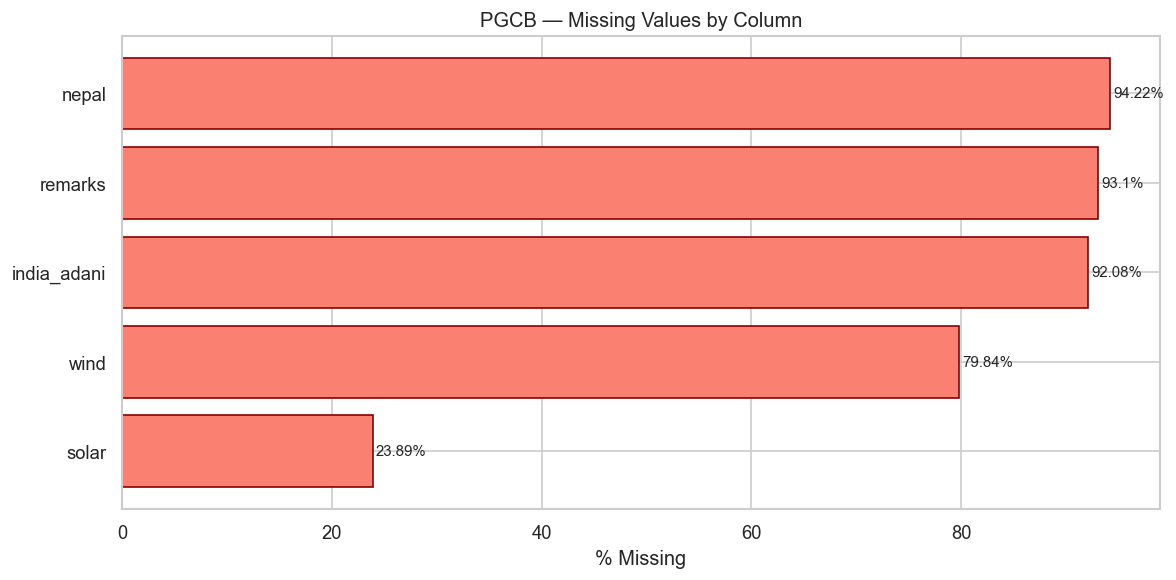

In [3]:
# Missing values bar chart
dl.plot_missing_bar(pgcb_raw)

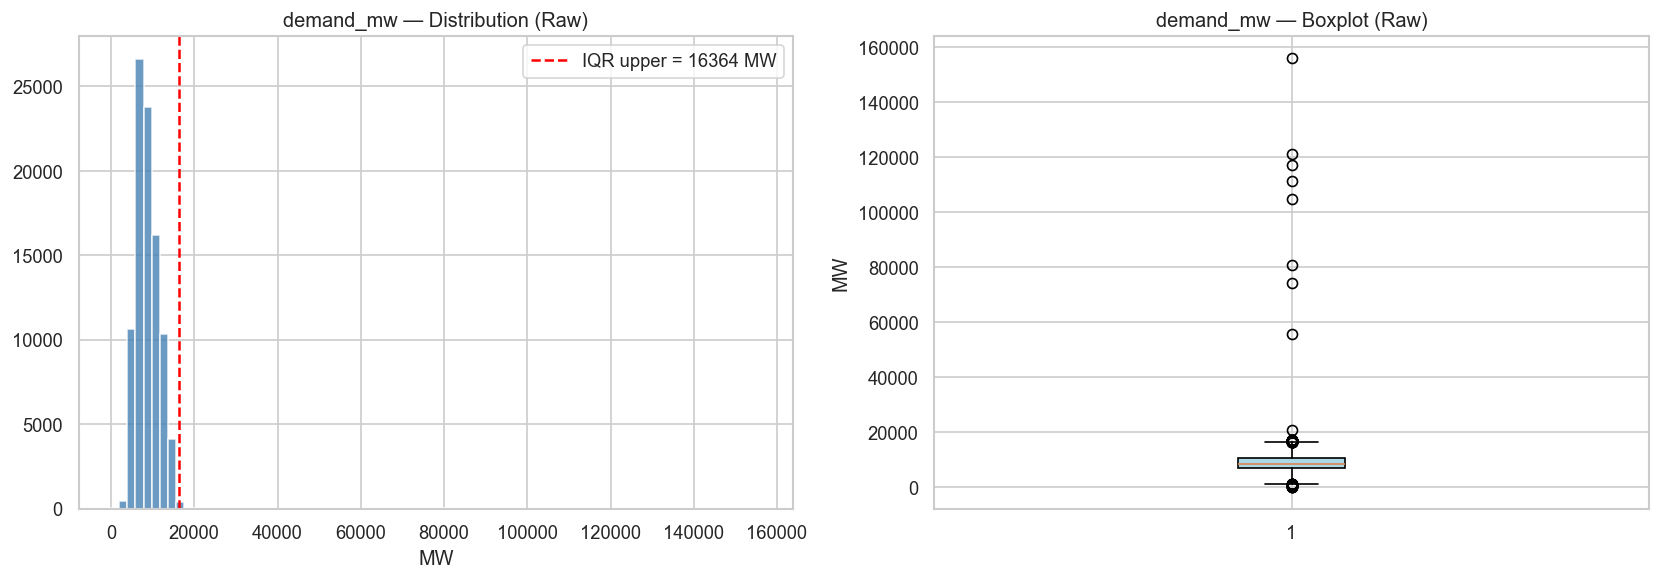

In [4]:
# Demand distribution: histogram + boxplot (with IQR upper bound marked)
dl.plot_demand_distribution(pgcb_raw)

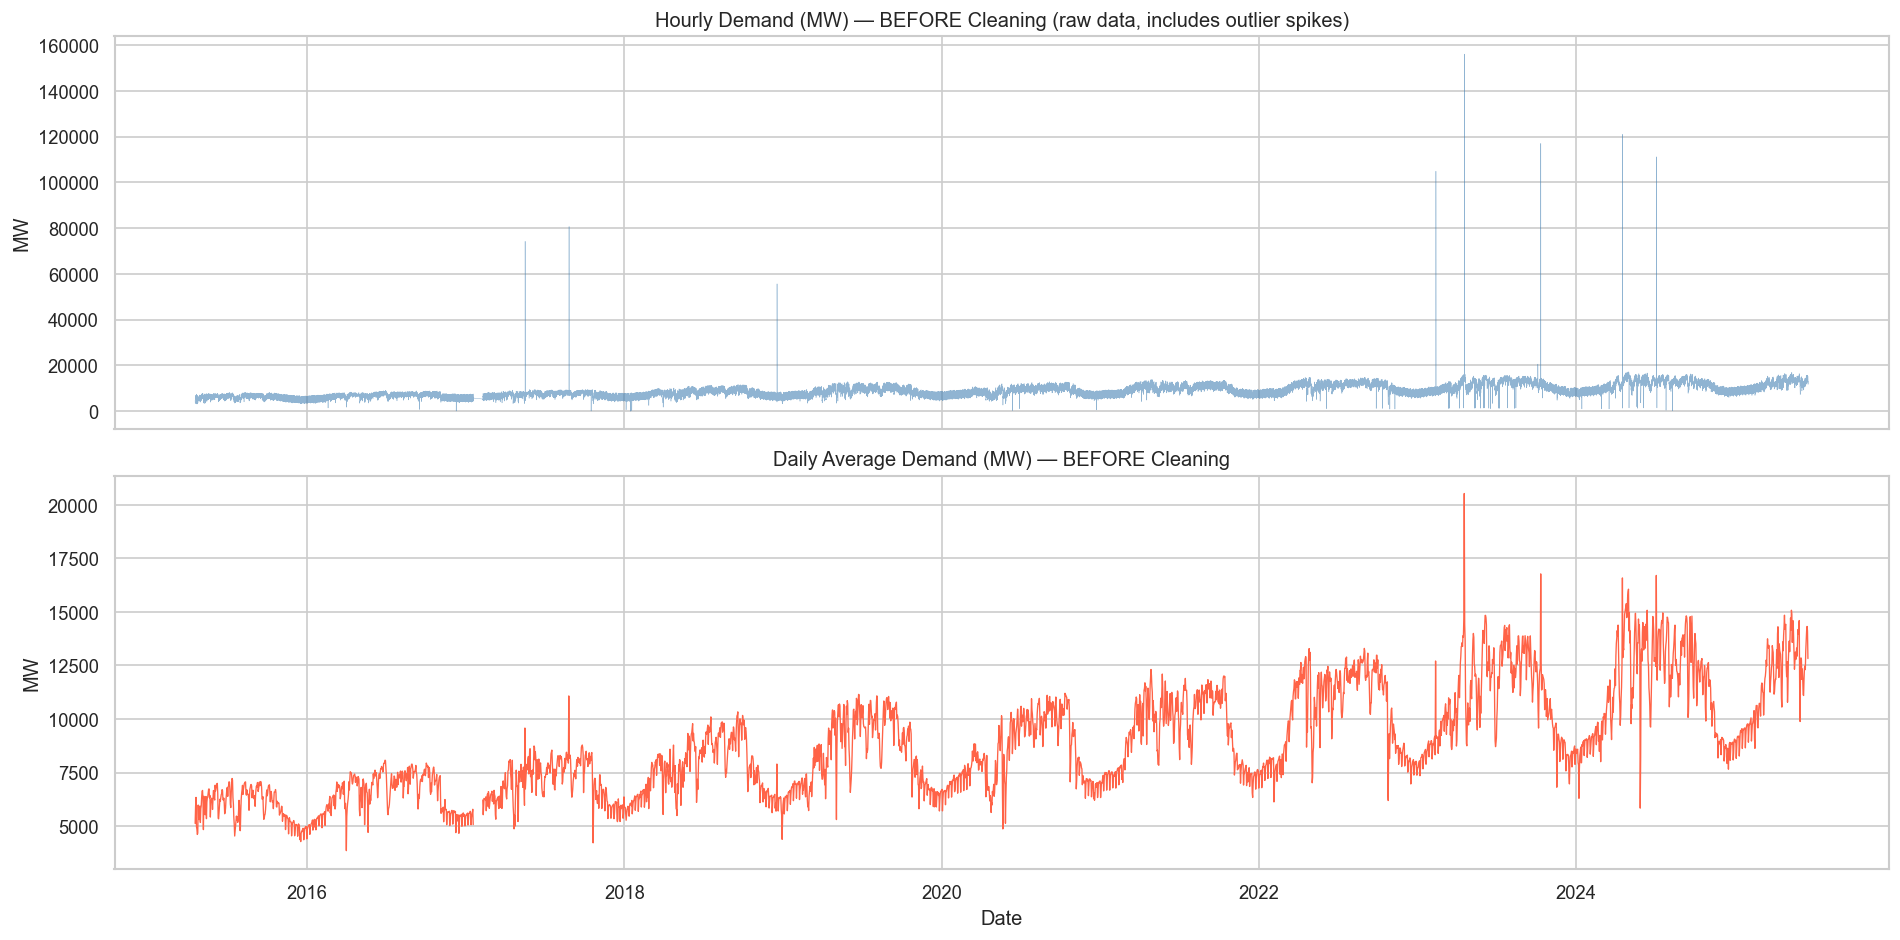

In [5]:
# Full time series — RAW (before cleaning — note the outlier spikes)
dl.plot_time_series_raw(pgcb_raw)

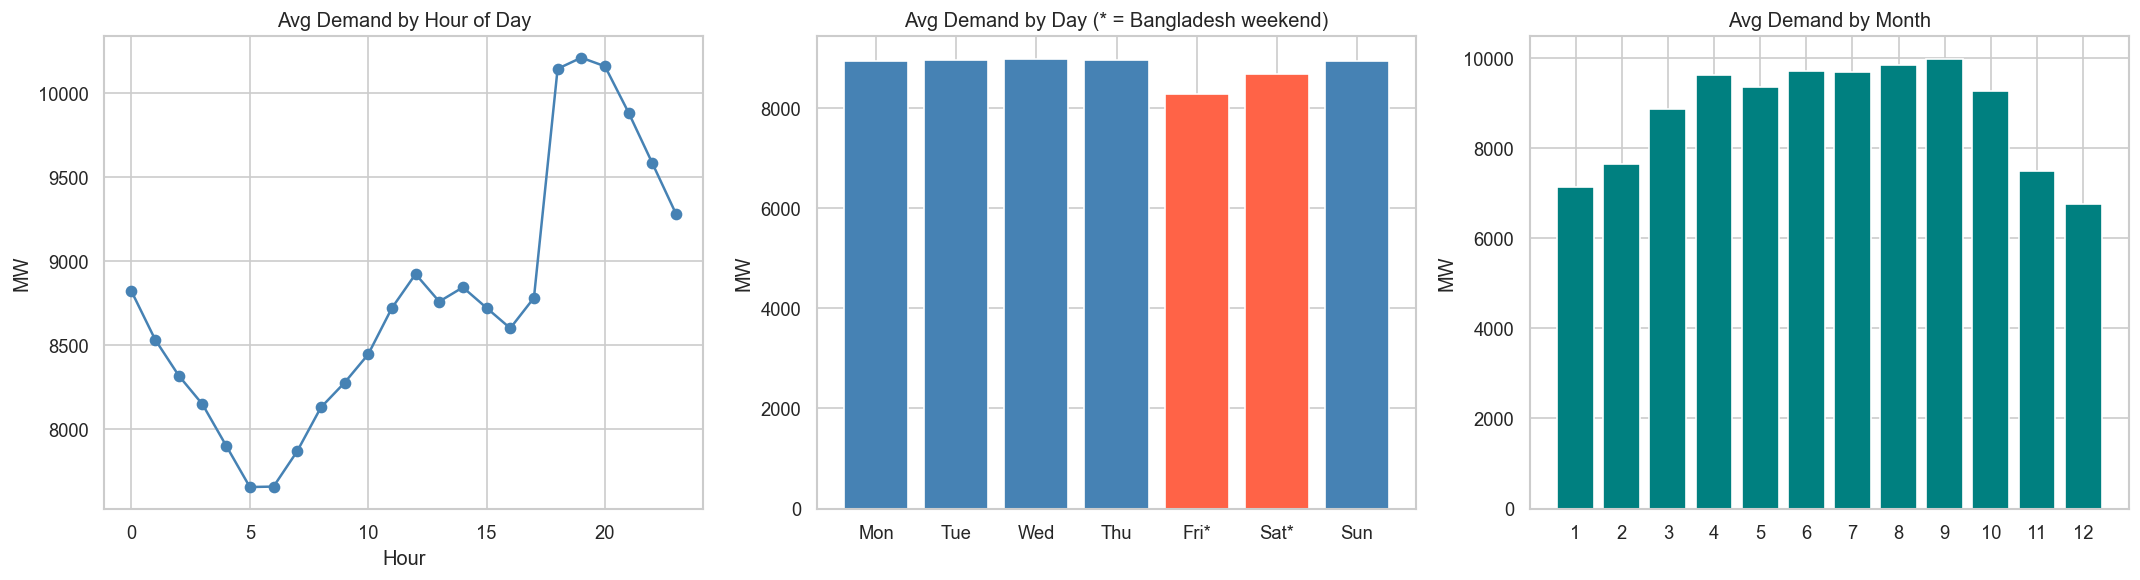

In [6]:
# Seasonality patterns: hour of day / day of week / month
dl.plot_seasonality(pgcb_raw)

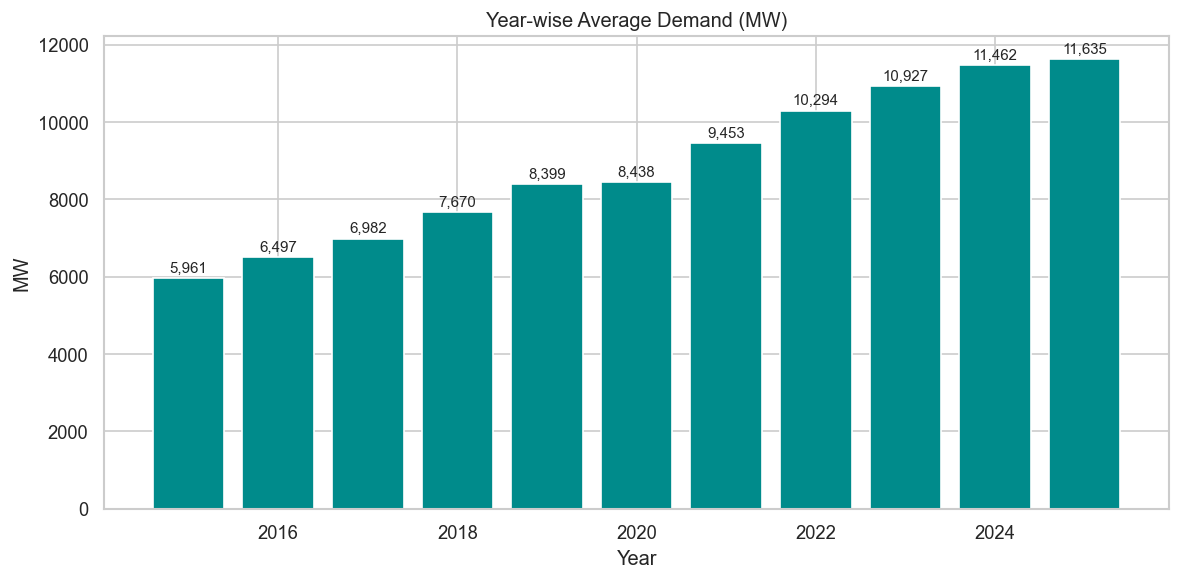

Growth: 5,961 MW (2015) → 11,635 MW (2025)


In [7]:
# Year-wise demand growth
dl.plot_yearly_growth(pgcb_raw)

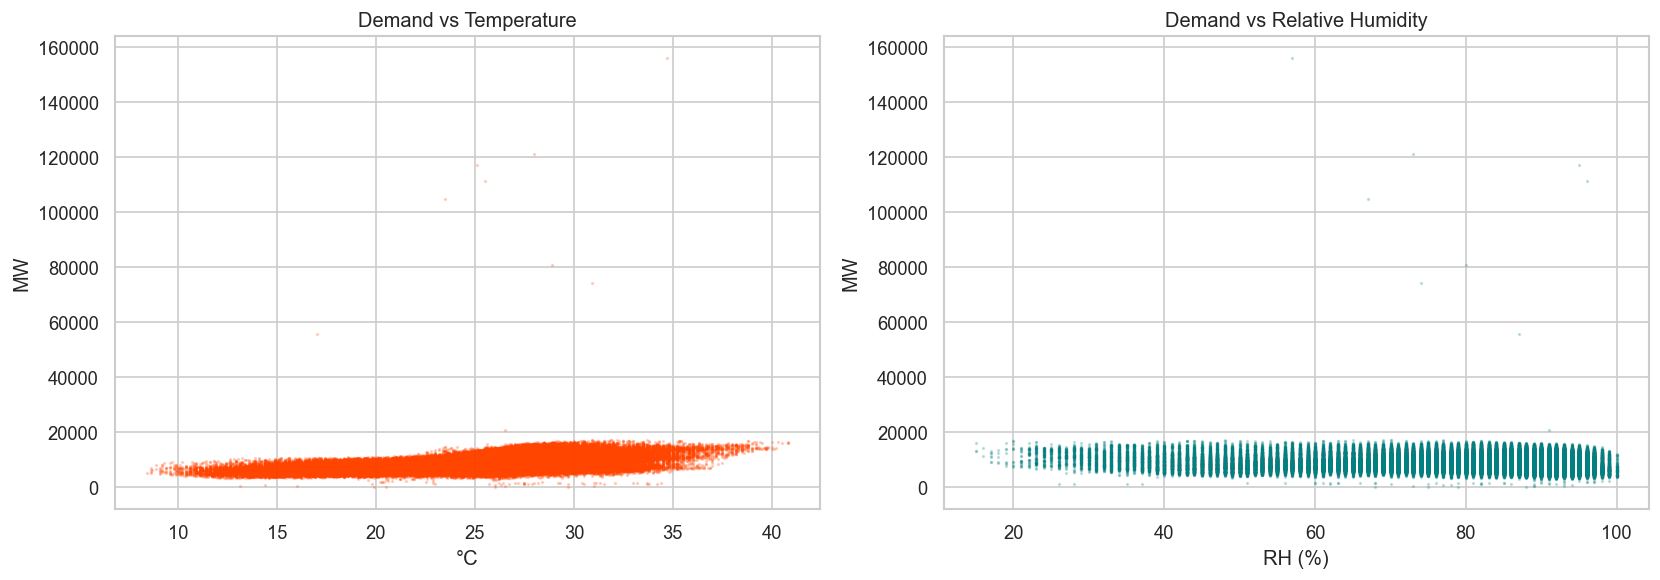

Pearson r — Temperature vs Demand : 0.448
Pearson r — Humidity vs Demand    : -0.088


In [8]:
# Demand vs temperature & humidity
dl.plot_demand_vs_weather(pgcb_raw, weather_raw)

---
## 🧹 Step 3 — Clean & Merge

In [9]:
# Clean PGCB: resample to 1H, remove outliers, KNN impute
pgcb_clean = dl.clean_pgcb(pgcb_raw)

Dropped columns   : ['remarks', 'india_adani', 'nepal', 'wind']
After 1H resample : 88,050 rows
  Frequency check : None
Outliers (demand_mw → NaN): 87
NaNs before KNN impute:
demand_mw       87
solar        20520
dtype: int64


KNN imputation done. Remaining NaNs: 0


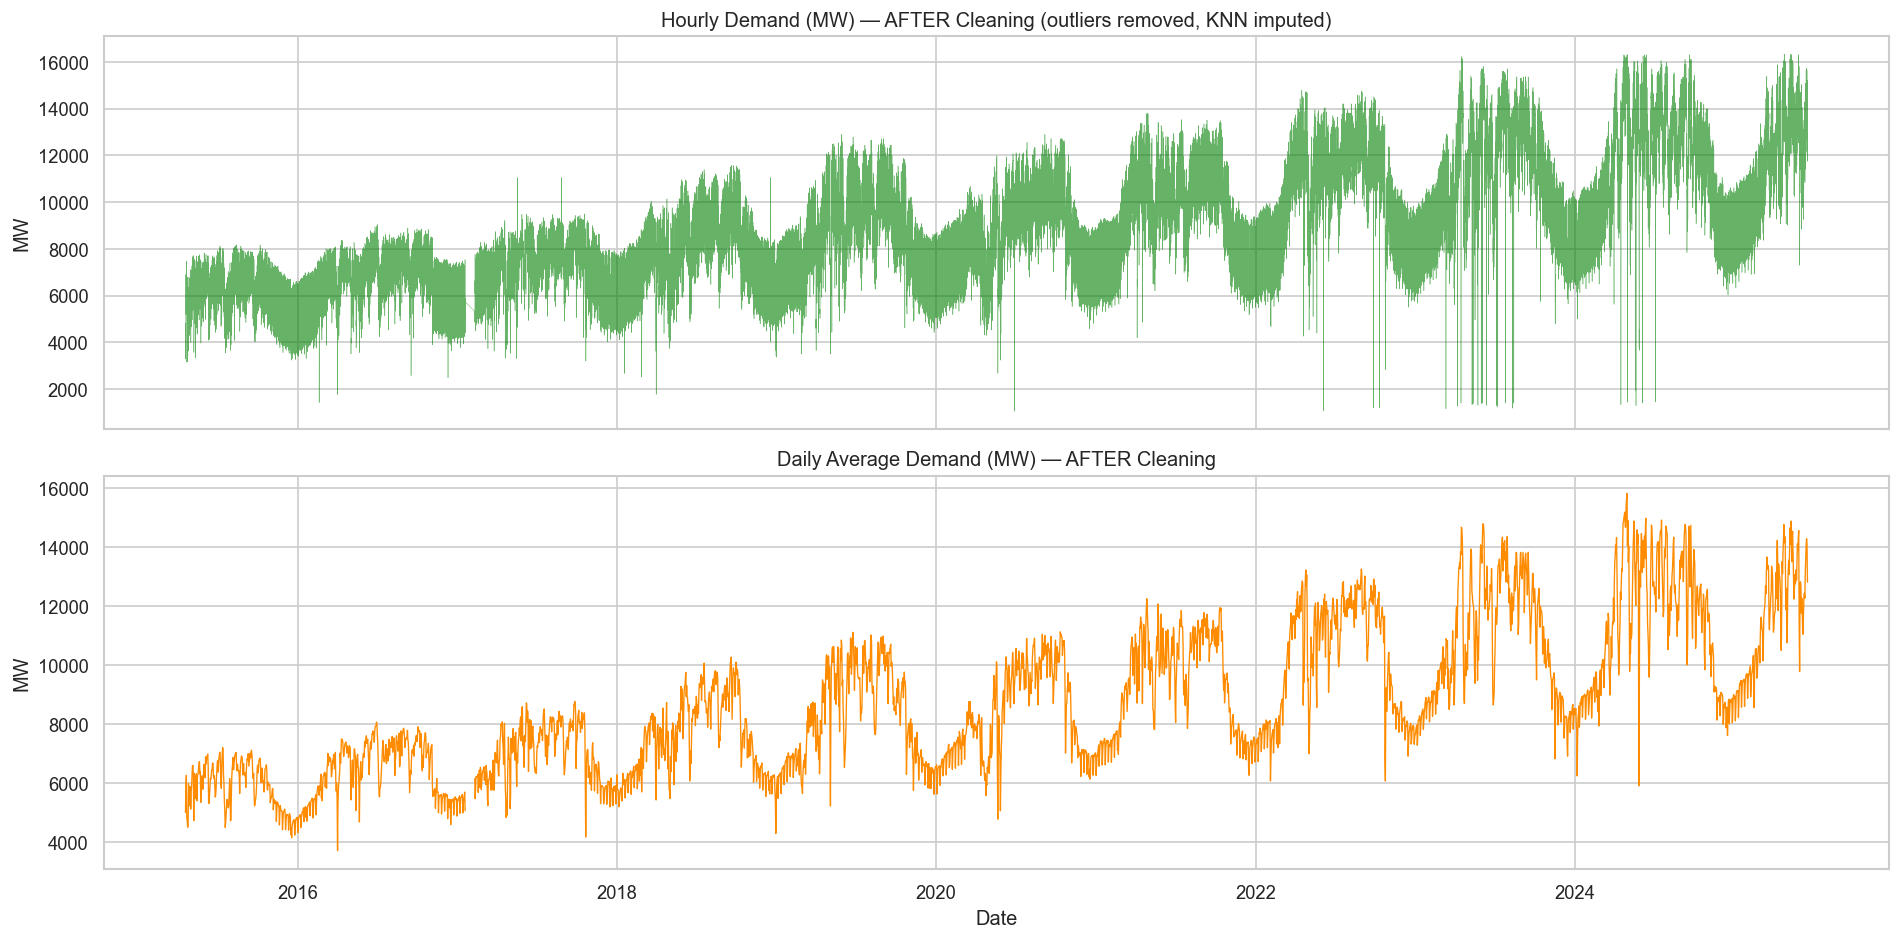

In [10]:
# Post-cleaning time series — compare with the raw plot above
# (outlier spikes are now gone, replaced by smooth KNN-imputed values)
dl.plot_time_series_clean(pgcb_clean)

In [11]:
# Clean weather: filter date range, drop redundant features
weather_clean = dl.clean_weather(weather_raw)

Weather cleaned   : 98,544 rows
  Date range      : 2015-01-01 00:00:00 → 2026-03-29 23:00:00
  Features kept   : ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'dew_point_2m', 'wind_direction_10m', 'cloud_cover', 'sunshine_duration']


In [12]:
# Process economic indicators: keyword filter → melt → pivot → ffill
econ_pivot = dl.process_economic(econ_raw, config.ECON_KEYWORDS)

Economic indicators selected: 47
Economic pivot    : (11, 47) (years 2015–2025)
  Remaining NaNs  : 0


In [13]:
# Merge all three sources into a single hourly DataFrame
df_merged = dl.merge_all(pgcb_clean, weather_clean, econ_pivot)

After PGCB + Weather merge : (88050, 17)
Final merged shape : 88,050 rows × 64 cols
  Date range       : 2015-04-19 00:00:00 → 2025-06-17 12:00:00
  Remaining NaNs   : 0


---
## ⚙️ Step 4 — Feature Engineering

In [14]:
# Build all features: calendar, lags, rolling aggregates
df_features = fe.build_features(df_merged)

Calendar features added:
                     hour  dayofweek  month  quarter  is_weekend  is_day_peak  \
datetime                                                                        
2015-04-19 00:00:00     0          6      4        2           0            0   
2015-04-19 01:00:00     1          6      4        2           0            0   
2015-04-19 02:00:00     2          6      4        2           0            0   
2015-04-19 03:00:00     3          6      4        2           0            0   
2015-04-19 04:00:00     4          6      4        2           0            0   

                     is_evening_peak  
datetime                              
2015-04-19 00:00:00                0  
2015-04-19 01:00:00                0  
2015-04-19 02:00:00                0  
2015-04-19 03:00:00                0  
2015-04-19 04:00:00                0  
Lag features added : ['demand_lag_1h', 'demand_lag_2h', 'demand_lag_3h', 'demand_lag_24h', 'demand_lag_48h', 'demand_lag_168h']
Rollin

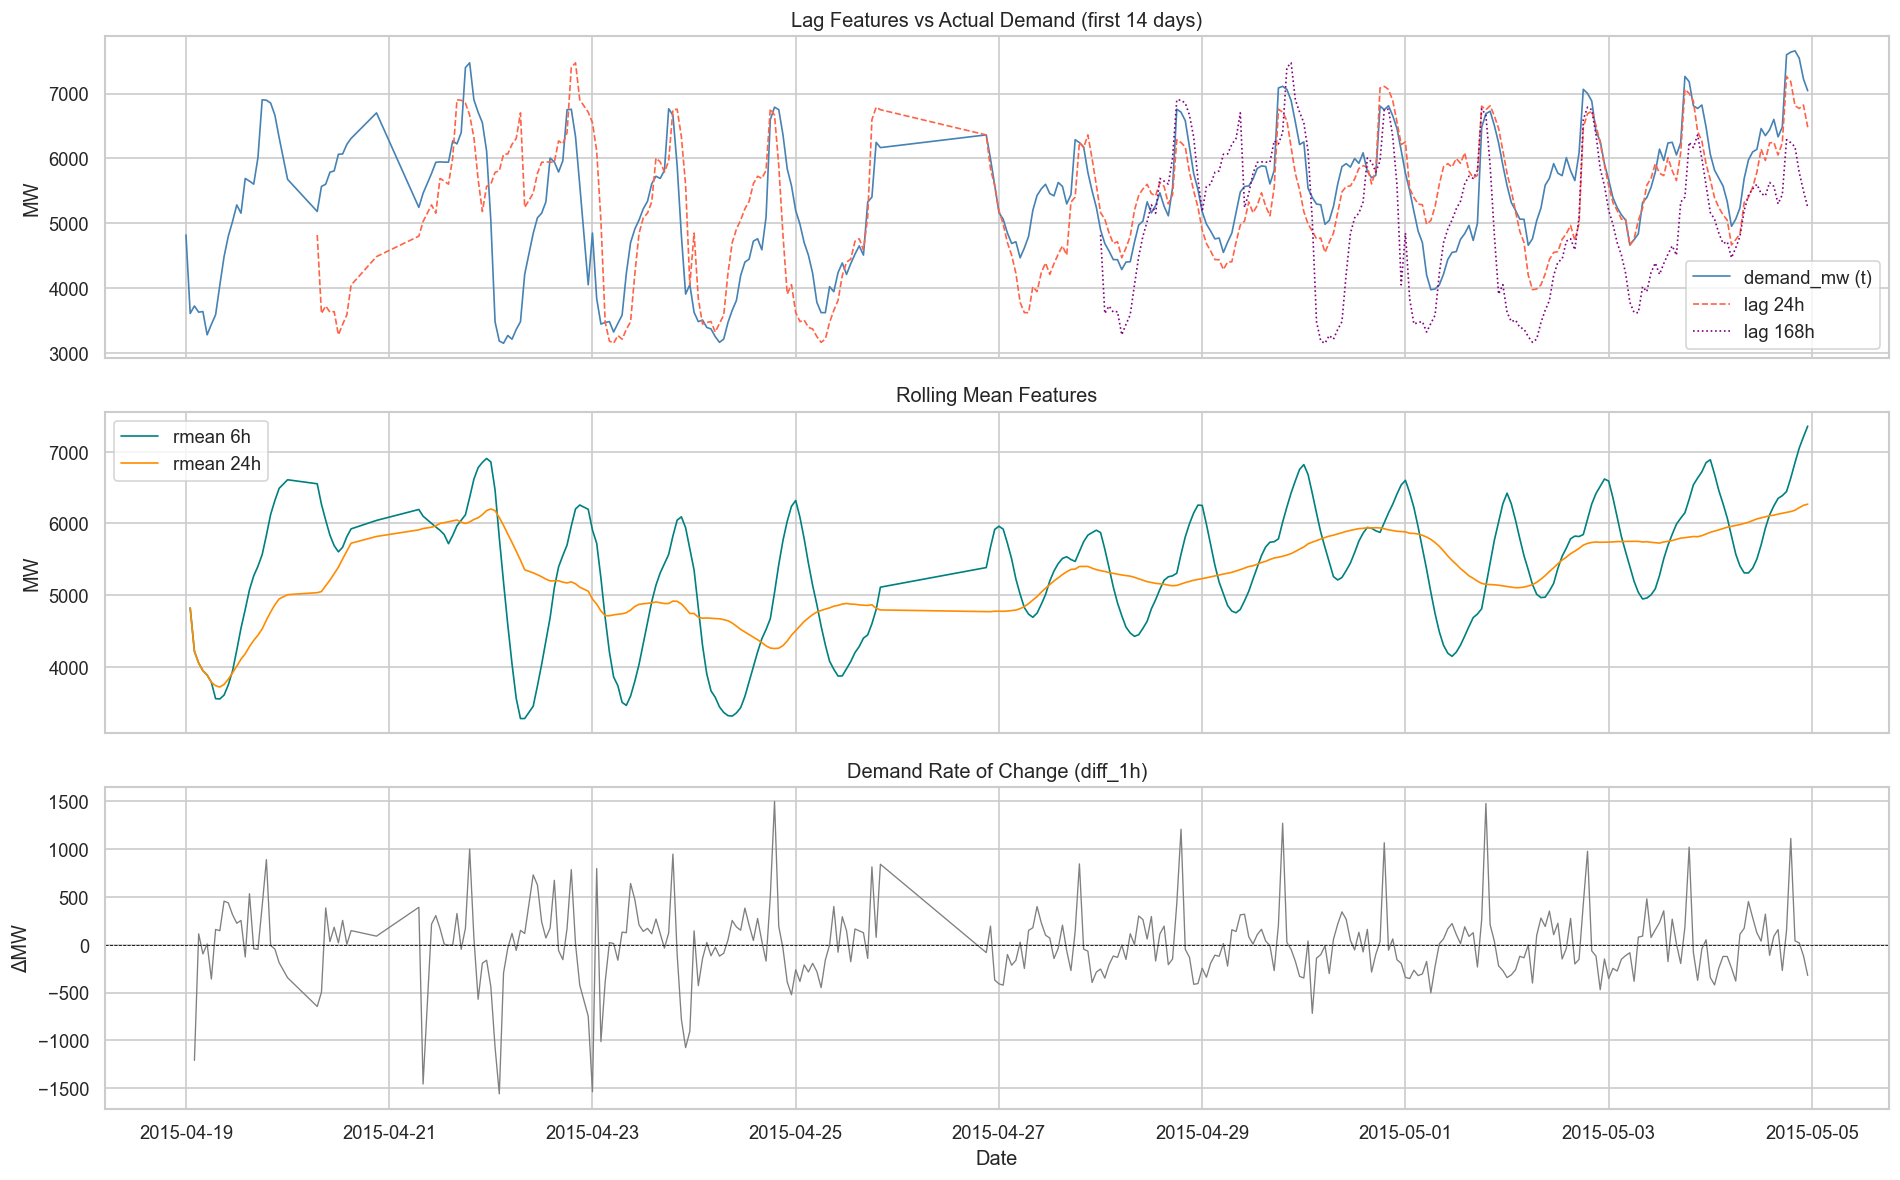

In [15]:
# Visualise lag and rolling features on a 2-week sample
fe.plot_lag_rolling(df_features, n_days=14)

In [16]:
# Add supervised target (demand at t+1) and drop NaN rows
df_final = fe.add_target(df_features)

After dropping NaN rows : 87,881 rows remaining


In [17]:
# Chronological split + StandardScaler (fit on train only)
X_train, X_test, y_train, y_test, feature_cols, scaler = fe.split_and_scale(df_final)

Leaky columns excluded : ['generation_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'india_bheramara_hvdc', 'india_tripura']
Feature count          : 77

Train : 75,092 rows  (2015-04-28 → 2023-12-31)
Test  : 12,789 rows  (2024-01-01 → 2025-06-17)
Target — Train mean: 8,330 MW | Test mean: 11,452 MW

✅ Zero leakage confirmed — train ends strictly before test starts.
✅ StandardScaler fitted on train only, applied to both splits.


---
## 🤖 Step 5 — Model Training

In [18]:
# 5.1  Random Forest
rf_model = mdl.train_random_forest(X_train, y_train)

Training Random Forest …


  ✅ Random Forest training complete.


In [19]:
# 5.2  XGBoost
xgb_model = mdl.train_xgboost(X_train, y_train, X_test, y_test)

Training XGBoost …
[0]	validation_0-rmse:3801.05723


[100]	validation_0-rmse:618.57026


[200]	validation_0-rmse:530.44333


[300]	validation_0-rmse:526.00786


[400]	validation_0-rmse:527.48152


[500]	validation_0-rmse:529.68521


[600]	validation_0-rmse:533.98991


[700]	validation_0-rmse:536.49047


[799]	validation_0-rmse:540.41835


  ✅ XGBoost training complete.


In [20]:
# 5.3  LightGBM
lgb_model = mdl.train_lightgbm(X_train, y_train, X_test, y_test)

Training LightGBM …


  ✅ LightGBM training complete.


---
## 📈 Step 6 — Evaluation

In [21]:
# Generate predictions from all models + ensemble
rf_pred  = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)
ens_pred = mdl.ensemble_predict(rf_pred, xgb_pred, lgb_pred)

In [22]:
# Compare all models on MAPE
results = mdl.evaluate_models(y_test, rf_pred, xgb_pred, lgb_pred, ens_pred)


   MODEL COMPARISON — Test MAPE
        Model  MAPE (%)
     Ensemble  3.137908
     LightGBM  3.187080
      XGBoost  3.276750
Random Forest  3.292742

🏆 Best Model : Ensemble  →  MAPE = 3.14%


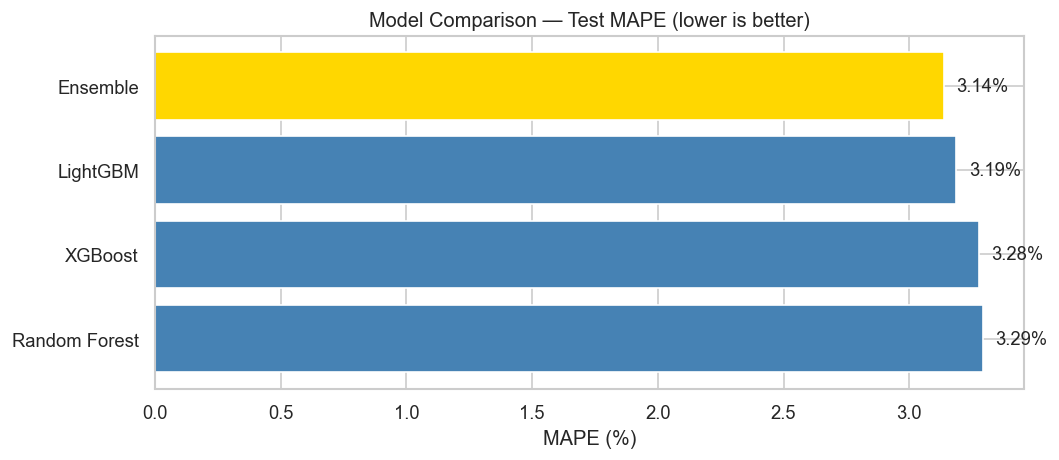

In [23]:
# Model comparison bar chart
mdl.plot_model_comparison(results)

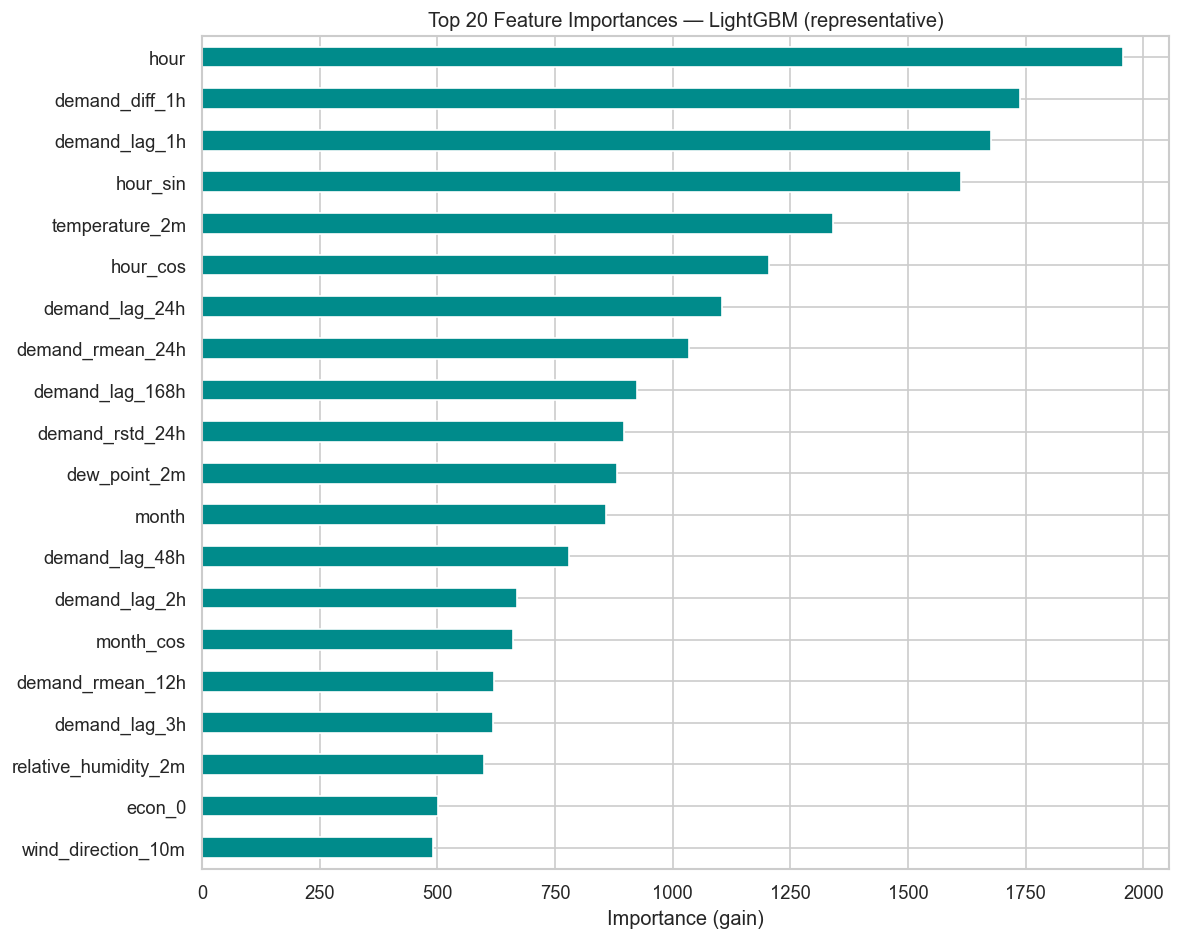

In [24]:
# Feature importance from the best individual model
best_name = results.iloc[0]["Model"]
best_pred = {"Random Forest": rf_pred, "XGBoost": xgb_pred,
             "LightGBM": lgb_pred, "Ensemble": ens_pred}[best_name]
best_mape = results.iloc[0]["MAPE (%)"]

best_model_map = {"Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgb_model}
fi_model      = best_model_map.get(best_name, lgb_model)
fi_label      = best_name if best_name in best_model_map else "LightGBM (representative)"
mdl.plot_feature_importance(fi_model, feature_cols, fi_label, top_n=20)

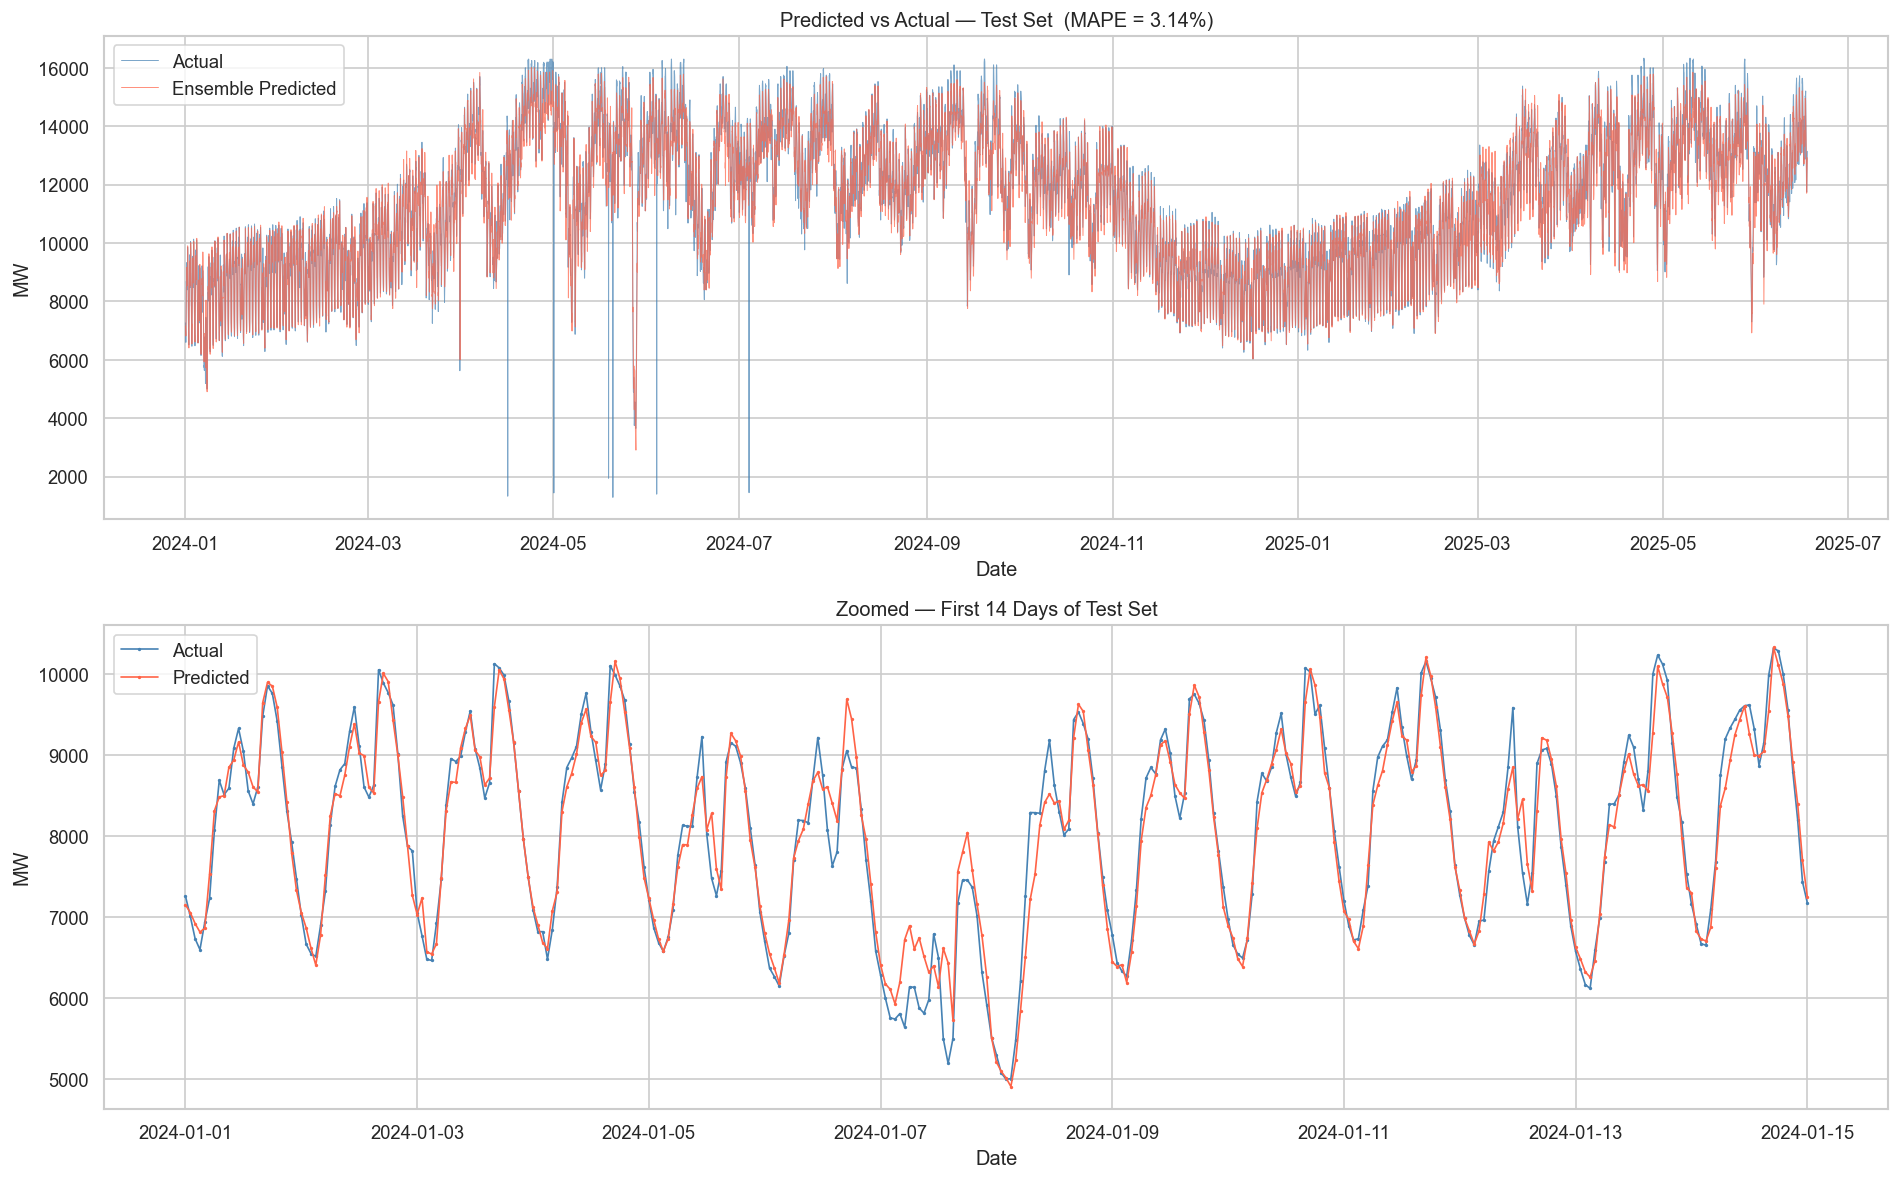

In [25]:
# Predicted vs Actual — full test set + zoomed 2-week view
mdl.plot_predictions(y_test, best_pred, best_name, best_mape, zoom_days=14)

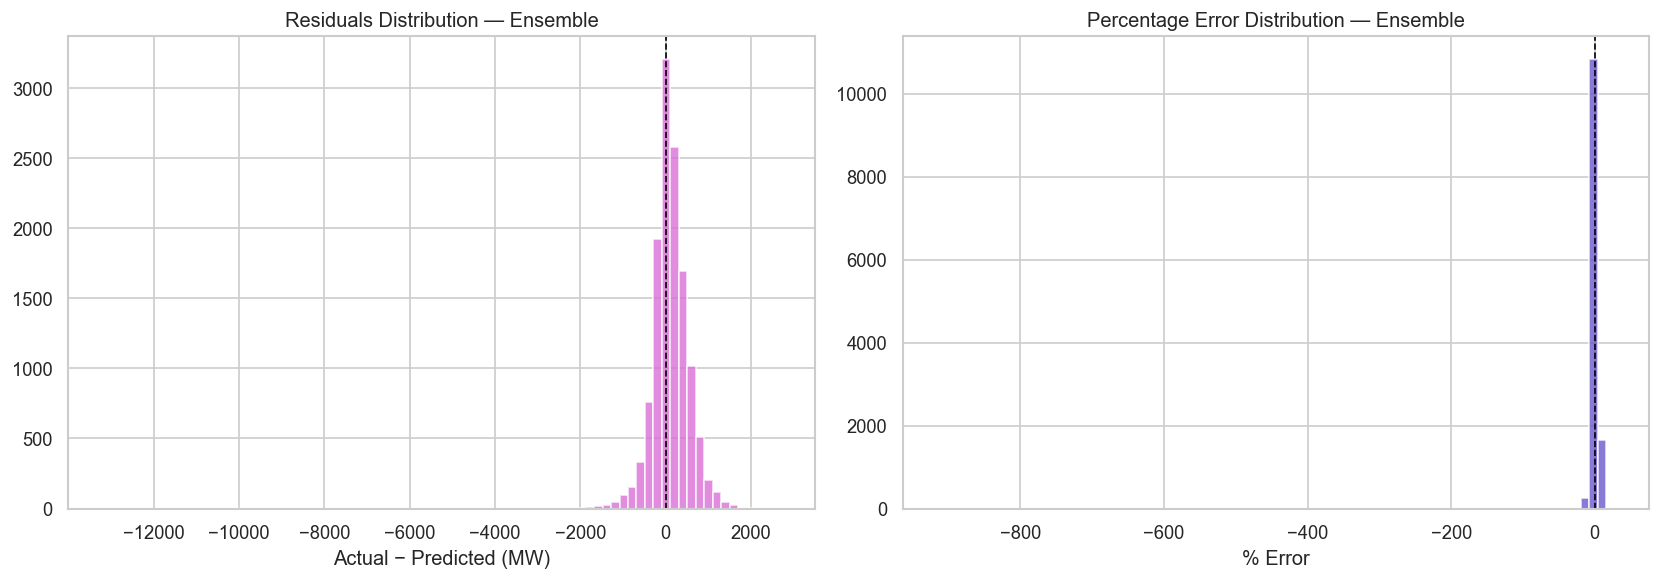

In [26]:
# Residuals distribution
mdl.plot_residuals(y_test, best_pred, best_name)

---
## 🏁 Step 7 — Final Results

In [27]:
mdl.print_final_metrics(y_test, best_pred, best_name)


  FINAL RESULTS — Ensemble
  MAPE : 3.14%
  MAE  : 322 MW
  RMSE : 503 MW
